In [1]:
import numpy as np
import pandas as pd

from tensorflow.keras.models  import Sequential
from tensorflow.keras.metrics import Accuracy 
from tensorflow.keras.layers import Dense, Conv2D, AveragePooling2D,Flatten,BatchNormalization, Dropout

from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import cv2
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

### Data Processing

In [35]:
image_size = (224,224)
# for now we are just rescaling the images

data_generator = ImageDataGenerator(rescale = 1/64, validation_split = 0.2,
                                    zoom_range=0.2, #zooms-in image 20% and zoom-out  80% 
                                    horizontal_flip=True,
                                    width_shift_range= 0.1, # shifts image -10% to +10%
                                    height_shift_range= 0.1, # shifts image -10% to +10% 
                                    shear_range = 0.1  #tilts image -10% to +10%
                                   )

train_generator = data_generator.flow_from_directory(r"C:\Velocity\Practice\2. Data_Science\Deep Learning\2.CNN\Images\Rice_image_Dataset", 
                                                     target_size = image_size, batch_size = 32, class_mode = 'categorical', subset = 'training')

val_generator = data_generator.flow_from_directory(r"C:\Velocity\Practice\2. Data_Science\Deep Learning\2.CNN\Images\Rice_image_Dataset",
                                                   target_size = image_size, batch_size = 32, class_mode = 'categorical', subset = 'validation')

Found 962 images belonging to 4 classes.
Found 240 images belonging to 4 classes.


### Model Building

In [3]:
model = Sequential()

# ---------CNN Layer---------
# 1st convolution layer
model.add(Conv2D(filters = 32, kernel_size = (3,3), strides = (1,1), activation = 'relu', input_shape = image_size +(3,)))
model.add(BatchNormalization()) # Stabilizes the outputs of the convolution
model.add(AveragePooling2D(pool_size=(2,2)))
model.add(Dropout(0.25)) # Randomly drops 25% of connections

# 2nd convolution layer
# Note: input_shape is only needed on the very first layer, so it is removed here.
model.add(Conv2D(filters = 16, kernel_size = (3,3), strides = (1,1), activation = 'relu'))
model.add(BatchNormalization())
model.add(AveragePooling2D(pool_size=(2,2))) 
model.add(Dropout(0.25))

model.add(Flatten())

#--------MLP Layer----------
model.add(Dense(units = 32, activation = 'relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5)) # Higher dropout (e.g., 50%) is common in fully connected layers

model.add(Dense(units = 16, activation = 'relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Output layer
model.add(Dense(units= 4, activation = 'softmax')) 

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 222, 222, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d (AveragePooling2D) │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 16)        │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 109, 109, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ average_pooling2d_1                  │ (None, 54, 54, 16)          │               0 │
│ (AveragePooling2D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 54, 54, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 46656)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │       1,493,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │              68 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,499,524 (5.72 MB)

 Trainable params: 1,499,332 (5.72 MB)

 Non-trainable params: 192 (768.00 B)

In [4]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)

# 2. Compile the model (using categorical_crossentropy for your 4 classes)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 3. Train the model with callbacks included
history = model.fit(
    train_generator, 
    validation_data=val_generator, 
    epochs=100, 
    callbacks=[early_stop, reduce_lr],
    verbose=1,
    batch_size = 32
)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 31s 883ms/step - accuracy: 0.3909 - loss: 1.4485 - val_accuracy: 0.6375 - val_loss: 1.0098 - learning_rate: 0.0010
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 27s 856ms/step - accuracy: 0.4979 - loss: 1.1891 - val_accuracy: 0.7167 - val_loss: 0.9140 - learning_rate: 0.0010
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 25s 814ms/step - accuracy: 0.5748 - loss: 1.0124 - val_accuracy: 0.3750 - val_loss: 1.2000 - learning_rate: 0.0010
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 25s 815ms/step - accuracy: 0.6372 - loss: 0.9057 - val_accuracy: 0.2583 - val_loss: 1.5565 - learning_rate: 0.0010
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 26s 851ms/step - accuracy: 0.7048 - loss: 0.7616 - val_accuracy: 0.2625 - val_loss: 1.6029 - learning_rate: 0.0010
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 25s 799ms/step - accuracy: 0.6975 - loss: 0.7602 - val_accuracy: 0.2583 - val_loss: 1.7723 - learning_rate: 2.0000e-04
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 26s 824ms/step - accuracy: 0.7370

In [5]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])

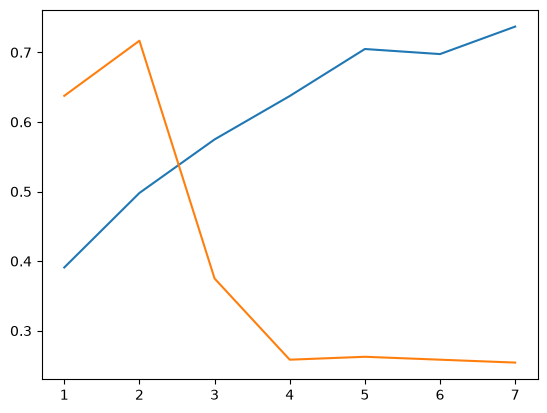

In [10]:
epoch_range = range(1,8)
plt.plot(epoch_range,history.history['accuracy'])
plt.plot(epoch_range,history.history['val_accuracy'])

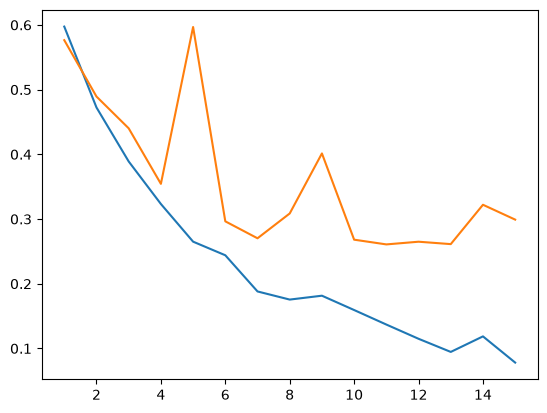

In [8]:
plt.plot(epoch_range,history.history['loss'])
plt.plot(epoch_range,history.history['val_loss'])

### Model Testing

In [18]:
img_path = r"C:\Velocity\Practice\2. Data_Science\Deep Learning\2.CNN\Images\Rice_image_Dataset\Ipsala\Ipsala (28).jpg"

In [19]:
img = image.load_img(img_path, target_size= image_size)
img_array = image.img_to_array(img)
img_array.shape

(224, 224, 3)

In [26]:
test_array = img_array.reshape(1,224,224,3)/255.0

In [27]:
ed_prob = model.predict(test_array)[0,0]
print(pred_prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
0.0


In [33]:
img_path = r"C:\Velocity\Practice\2. Data_Science\Deep Learning\2.CNN\Images\Rice_image_Dataset\Arborio\Arborio (258).jpg"

# 1. Load image (Ensure target_size matches the model you are testing: 224 or 64)
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)

# 2. Rescale pixels to 0-1 (Crucial: Must match the training data generator)
img_array = img_array / 255.0 

# 3. Reshape for prediction
test_array = img_array.reshape(1, 224, 224, 3)

# 4. Predict across all 4 classes
predictions = model.predict(test_array)
predicted_class = np.argmax(predictions) # Finds the index of the highest probability

print(f"Probabilities for all 4 classes: {predictions}")
print(f"Predicted Class Index: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Probabilities for all 4 classes: [[0.07297194 0.09323814 0.10147779 0.73231214]]
Predicted Class Index: 3


In [29]:
print(train_generator.class_indices)

{'Arborio': 0, 'Basmati': 1, 'Ipsala': 2, 'Jasmine': 3}


### Using Transfer Learning 
cause own neural network not predictiing properly

In [34]:
from tensorflow.keras.applications import VGG16

In [36]:
base_model = VGG16(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

# 2. Freeze the weights so you don't waste time retraining them
base_model.trainable = False

# 3. Build your final model wrapper
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax') # 4 classes for your rice dataset
])

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 27s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │       6,422,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 21,138,500 (80.64 MB)

 Trainable params: 6,423,812 (24.50 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [37]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2)

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_generator, 
    validation_data=val_generator, 
    epochs=20, # It will stop automatically much sooner
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 97s 3s/step - accuracy: 0.6674 - loss: 1.5055 - val_accuracy: 0.9500 - val_loss: 0.2052 - learning_rate: 0.0010
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 119s 4s/step - accuracy: 0.9148 - loss: 0.2597 - val_accuracy: 0.9792 - val_loss: 0.1009 - learning_rate: 0.0010
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 113s 4s/step - accuracy: 0.9220 - loss: 0.2029 - val_accuracy: 0.9542 - val_loss: 0.1194 - learning_rate: 0.0010
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 108s 4s/step - accuracy: 0.9501 - loss: 0.1439 - val_accuracy: 0.9708 - val_loss: 0.0883 - learning_rate: 0.0010
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 109s 4s/step - accuracy: 0.9522 - loss: 0.1357 - val_accuracy: 0.9792 - val_loss: 0.0650 - learning_rate: 0.0010
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step - accuracy: 0.9699 - loss: 0.1196 - val_accuracy: 0.9833 - val_loss: 0.0573 - learning_rate: 0.0010
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 97s 3s/step - accuracy: 0.9678 - loss: 0.1040 - val_accura

### Model Testing

In [48]:
img_path = r"C:\Velocity\Practice\2. Data_Science\Deep Learning\2.CNN\Images\Rice_image_Dataset\Ipsala\Ipsala (28).jpg"

# 1. Load image
img = image.load_img(img_path, target_size=(224, 224))

# 2. Process image for prediction
img_array = image.img_to_array(img)
img_array = img_array / 255.0 
test_array = img_array.reshape(1, 224, 224, 3)

# 3. Predict across all 4 classes
predictions = model.predict(test_array)
predicted_class_index = np.argmax(predictions) 

# 4. Map index to class name
class_names = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine']
predicted_class_name = class_names[predicted_class_index]

print(f"Probabilities for all 4 classes: {predictions}")
print(f"Predicted Image Class Index is: {predicted_class_index}")
print(f"Predicted Image Class is: {predicted_class_name}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step
Probabilities for all 4 classes: [[1.6852261e-02 9.3979799e-07 9.8276734e-01 3.7943508e-04]]
Predicted Image Class Index is: 2
Predicted Image Class is: Ipsala


In [42]:
print(train_generator.class_indices)

{'Arborio': 0, 'Basmati': 1, 'Ipsala': 2, 'Jasmine': 3}


### Save the Model

In [50]:
import json

# 1. Save the trained model (saves architecture, weights, and optimizer state)
model.save('rice_classifier_vgg16.keras') 

# 2. Save the class dictionary to a JSON file
class_names = ['Arborio', 'Basmati', 'Ipsala', 'Jasmine']
with open('class_names.json', 'w') as f:
    json.dump(class_names, f)